    Updating registry at `C:\Users\sales\.julia\registries\General.toml`
     Project No packages added to or removed from `C:\Users\sales\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\sales\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
   Installed x265_jll ───────────────────── v4.1.0+0
   Installed libdecor_jll ───────────────── v0.2.2+0
   Installed Opus_jll ───────────────────── v1.6.1+0
   Installed JpegTurbo_jll ──────────────── v3.2.0+1
   Installed libfdk_aac_jll ─────────────── v2.0.4+0
   Installed Libmount_jll ───────────────── v2.42.0+0
   Installed LERC_jll ───────────────────── v4.1.0+0
   Installed Xorg_xcb_util_wm_jll ───────── v0.4.2+0
   Installed Grisu ──────────────────────── v1.0.2
   Installed Measures ───────────────────── v0.3.3
   Installed GR ─────────────────────────── v0.73.27
   Installed Contour ────────────────────── v0.6.3
   Installed GR_jll ─────────────────────── v0.73.

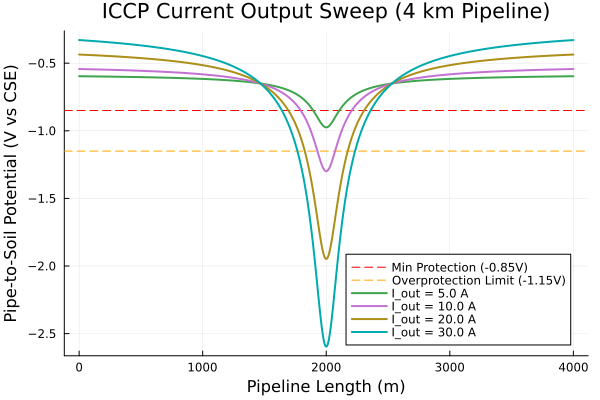

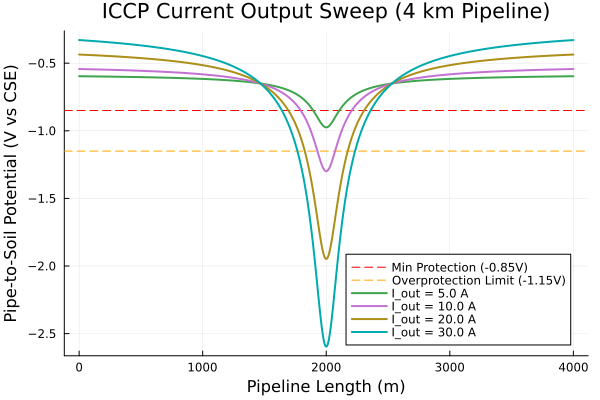

In [ ]:
import Pkg
Pkg.add("LinearAlgebra")
Pkg.add("Plots")
using LinearAlgebra
using Plots

"""
    simulate_iccp_correct(; L, D, wt, rho_soil, R_c, rho_steel, anode_pos, x_drain, I_outs, N)

模擬長度 4 公里沉埋管線在不同 ICCP 電流輸出下的沿線管對土電位分布。
"""

function simulate_iccp_correct(;
    L = 4000.0,             # 管線總長 (m)
    D = 0.5,                # 外徑 (m)
    wt = 0.0095,            # 壁厚 (m)
    rho_soil = 50.0,        # 土壤電阻率 (Ω·m)
    R_c = 2000.0,           # 防蝕塗層電阻 (Ω·m²) - 採一般使用中管線合理值
    rho_steel = 1.7e-7,     # 鋼管電阻率 (Ω·m)
    E_nat = -0.65,          # 自然腐蝕電位 (V vs CSE)
    anode_pos = (2000.0, 100.0, 2.0), # 陽極位置 (x=2000m, y=偏置100m, z=2m)
    x_drain = 2000.0,       # 整流器負極接管位置 (排流點, x=2000m)
    I_outs = [0.2, 0.5, 1.0, 2.0],    # 理性的 ICCP 輸出電流 (A)
    N = 4001                # 網格節點數
)
    x = range(0, L, length=N)
    dx = L / (N - 1)
    
    A_m = π * ((D/2)^2 - ((D - 2*wt)/2)^2) # 金屬截面積
    R_m = rho_steel / A_m                 # 單位長度金屬電阻 (Ω/m)
    P = π * D                             # 管道周長 (m)
    k = (R_m * P) / R_c                   # 衰減常數
    
    # 建立有限差分矩陣 A
    A = zeros(Float64, N, N)
    for i in 2:N-1
        A[i, i-1] = 1 / dx^2
        A[i, i]   = -2 / dx^2 - k
        A[i, i+1] = 1 / dx^2
    end
    
    # 端點絕緣邊界 (dV/dx = 0)
    A[1, 1] = -1/dx; A[1, 2] = 1/dx
    A[N, N] = 1/dx;  A[N, N-1] = -1/dx

    p = plot(
        title = "Corrected ICCP Protection Profile (4 km Pipeline)",
        xlabel = "Pipeline Distance (m)",
        ylabel = "Pipe-to-Soil Potential (V vs CSE)",
        legend = :bottomright,
        grid = true
    )

    hline!(p, [-0.85], line=(:dash, :red), label="Min Protection (-0.85V)")
    hline!(p, [-1.15], line=(:dash, :orange), label="Overprotection (-1.15V)")

    idx_drain = round(Int, (x_drain / L) * (N - 1)) + 1

    for I_out in I_outs
        # 1. 陽極地床注入土壤之電位場 V_soil
        xa, ya, za = anode_pos
        r = @. sqrt((x - xa)^2 + ya^2 + za^2)
        V_soil = @. (I_out * rho_soil) / (2 * π * r)
        
        # 2. 建立右邊向量 b (包含塗層洩漏與負極排流點的集中汲取)
        b = zeros(Float64, N)
        for i in 2:N-1
            b[i] = -k * (V_soil[i] + E_nat)
        end
        
        # 關鍵修正：在排流點注入負極汲取電流點源 (Delta function, I_out/dx)
        b[idx_drain] += (R_m * I_out) / dx
        
        b[1] = 0.0
        b[N] = 0.0
        
        # 3. 求解管壁金屬電位 V_p
        V_p = A \ b
        
        # 4. 計算斷電電位 / 管對土電位 E_off
        E_off = V_p .- V_soil
        
        plot!(p, x, E_off, label="I_out = $(I_out) A", lw=2)
    end

    display(p)
    return p
end

simulate_iccp_correct()